<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
!pip install -q \
gdown \
torch \
transformers==4.39.3 \
accelerate \
bitsandbytes \
sentence-transformers \
faiss-cpu \
openpyxl \
datasets \
umap-learn \
ragatouille==0.0.8 \
langchain==0.1.16 \
langchain-community==0.0.32 \
langchain-core==0.1.42 \
langchain-text-splitters==0.0.1

In [2]:
import gdown
import pandas as pd
import faiss
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain_core.documents import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel
from langchain_text_splitters import RecursiveCharacterTextSplitter

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## Загрузка данных (4 балла)

In [3]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=248e2fb5-548f-4888-b98b-68a2335bae07
To: /content/file.csv
100%|██████████| 672M/672M [00:04<00:00, 154MB/s]


In [4]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [5]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [6]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

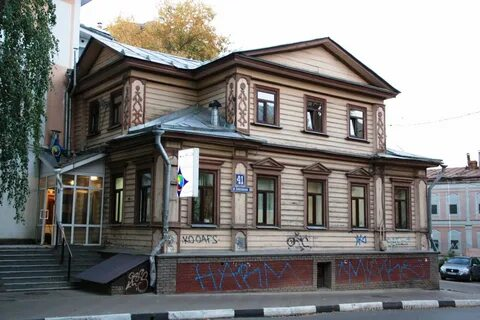

In [7]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [8]:


df = pd.read_csv('file.csv')

df = df[df["description"].notna()]
df["description"] = df["description"].astype(str)

# длина
df["desc_len"] = df["description"].str.len()
df = df[(df["desc_len"] > 20) & (df["desc_len"] < 500)]

# простая фильтрация мусора
bad_patterns = ["selfie", "instagram", "person", "man", "woman"]
df = df[~df["description"].str.lower().str.contains("|".join(bad_patterns))]


def combine_texts(texts):
    texts = list(set(texts))
    return " ".join(texts[:3])

agg_df = (
    df.groupby("WikiData")
      .agg({
          "Name": "first",
          "City": "first",
          "description": combine_texts,
          "Lat": "first",
          "Lon": "first"
      })
      .reset_index()
)


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)

documents = []

for _, row in agg_df.iterrows():
    text = row["description"]

    if len(text) < 300:
        chunks = [text]
    else:
        chunks = text_splitter.split_text(text)

    for chunk in chunks:
        documents.append(
            LangchainDocument(
                page_content=chunk,
                metadata={
                    "name": row["Name"],
                    "city": row["City"],
                    "lat": row["Lat"],
                    "lon": row["Lon"]
                }
            )
        )

print(f"Documents: {len(documents)}")


EMBEDDING_MODEL_NAME = "thenlper/gte-small"
embed_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

texts = [doc.page_content for doc in documents]
embeddings = embed_model.encode(texts, normalize_embeddings=True, show_progress_bar=True)



dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(np.array(embeddings))


Documents: 239


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [9]:
reranker = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

def retrieve_rerank(query, k=10, final_k=5):
    q_emb = embed_model.encode([query], normalize_embeddings=True)
    scores, ids = index.search(q_emb, k)

    candidates = [documents[i] for i in ids[0]]
    texts = [d.page_content for d in candidates]

    reranked = reranker.rerank(query, texts)
    top_idx = [r["result_index"] for r in reranked[:final_k]]

    return [candidates[i] for i in top_idx]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()


In [10]:
generator = pipeline(
    "text-generation",
    model="Qwen/Qwen1.5-1.8B-Chat",
    device=0 if torch.cuda.is_available() else -1
)

def rag(query, k=5):
    docs = retrieve_rerank(query)
    context = "\n\n".join([d.page_content for d in docs])

    prompt = f"""
Ты туристический гид.

Вопрос:
{query}

Контекст:
{context}

Ответ:
"""

    out = generator(prompt, max_new_tokens=200, do_sample=True, temperature=0.7)
    return out[0]["generated_text"], docs

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.67G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

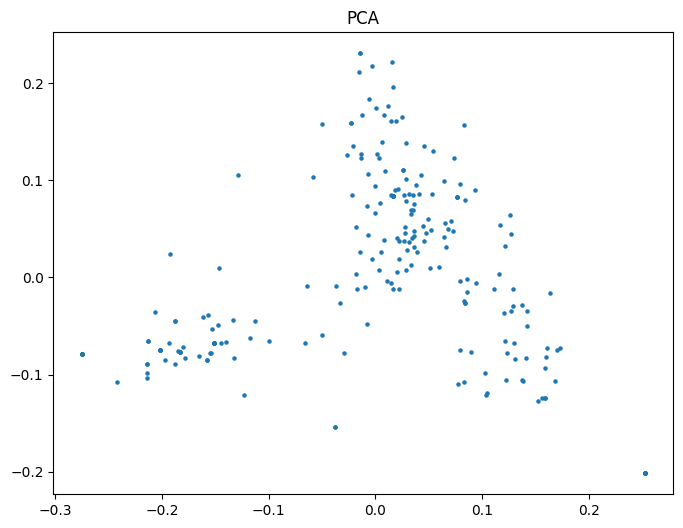

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


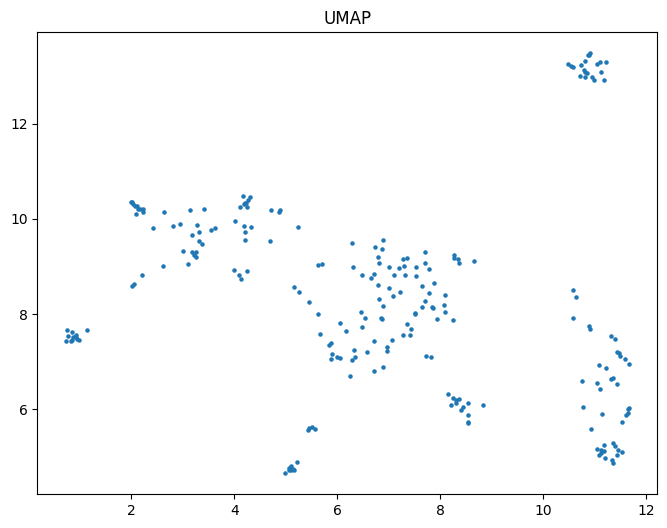

In [11]:
from sklearn.decomposition import PCA
import umap

emb_np = np.array(embeddings)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(emb_np)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], s=5)
plt.title("PCA")
plt.show()

umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(emb_np)

plt.figure(figsize=(8,6))
plt.scatter(umap_result[:,0], umap_result[:,1], s=5)
plt.title("UMAP")
plt.show()

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

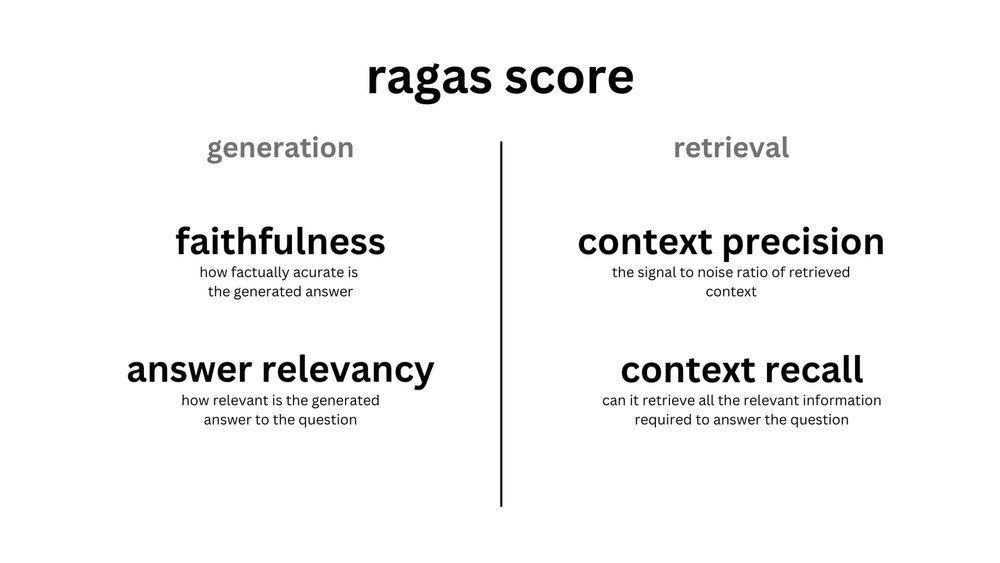

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [12]:
def data_preprocess(sample_size=100):
    sampled = agg_df.sample(sample_size, random_state=42)

    questions = []
    answers = []
    contexts = []

    for _, row in sampled.iterrows():
        context = row["description"]
        q = f"Что это за место: {row['Name']}?"

        ans, docs = rag(q)
        ctxs = [d.page_content for d in docs]

        questions.append(q)
        answers.append(ans)
        contexts.append(ctxs)

    return pd.DataFrame({
        "question": questions,
        "answer": answers,
        "contexts": contexts
    })

In [13]:
def answer_relevancy(df):
    scores = []

    for _, row in df.iterrows():
        q_emb = embed_model.encode(row["question"], normalize_embeddings=True)
        a_emb = embed_model.encode(row["answer"], normalize_embeddings=True)

        score = np.dot(q_emb, a_emb)
        scores.append(score)

    return np.mean(scores)

# Протестируйте ваш RAG (3 балла)

In [14]:
df_eval = data_preprocess(100)
score = answer_relevancy(df_eval)

print("Answer relevancy:", score)

/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()
100%|██████████| 1/1 [00:00<00:00, 54.99it/s]


WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


100%|██████████| 1/1 [00:00<00:00, 55.11it/s]


WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


100%|██████████| 1/1 [00:00<00:00, 45.89it/s]


...

WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


100%|██████████| 1/1 [00:00<00:00, 57.67it/s]


WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


100%|██████████| 1/1 [00:00<00:00, 33.19it/s]


Answer relevancy: 0.92174876


# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [15]:
def precision_at_k(query, k=5):
    docs = retrieve_rerank(query, final_k=k)
    rel = 0

    for d in docs:
        if query.lower() in d.page_content.lower():
            rel += 1

    return rel / k

queries = df_eval["question"].tolist()[:20]
scores = [precision_at_k(q) for q in queries]

print("Precision@k:", np.mean(scores))

100%|██████████| 1/1 [00:00<00:00, 60.98it/s]


WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


100%|██████████| 1/1 [00:00<00:00, 47.41it/s]


WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


100%|██████████| 1/1 [00:00<00:00, 60.81it/s]


WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


100%|██████████| 1/1 [00:00<00:00, 59.14it/s]


WARNING! Your documents have duplicate entries!  This will slow down calculation and may yield subpar results


100%|██████████| 1/1 [00:00<00:00, 47.06it/s]

Precision@k: 0.0
